# AQI Forecasting — XGBoost Model
**Dataset:** `IITG_AQI_cleaned.csv`  
**Station:** IITG  
**Rows:** 28,780 hourly observations (Sep 2022 – Dec 2025)  
**Features:** 20 pollutant + weather columns + AQI target + AQI_Category  
**Target:** AQI (continuous)  
**Model:** XGBoost with lag + cyclic calendar + pollutant features  

---
> **EDA findings applied here (EDA notebook — Sections 8, 9, 10):**
> - Dominant pollutants: PM25, PM10, CO, NOx (highest positive r with AQI)
> - Negative correlators: O3, WS (wind disperses pollutants)
> - Multicollinearity: NO↔NOx (r=0.99), PM25↔PM10, Benzene↔Toluene — kept as-is (trees handle it)
> - Strong annual seasonality (Nov–Jan peak) and dual rush-hour pattern (8–10h, 20–22h)
> - ACF lag-1 ≈ 0.887 → lag features are the single strongest predictors
> - Dataset is complete — zero missing values
> - XGBoost: **hourly granularity preferred** (more rows = better tree generalisation)
> - 70 / 15 / 15 **chronological** train / val / test split — no random shuffling


## 0. Environment Setup


In [1]:
# Uncomment if running for the first time
# !pip install pandas numpy matplotlib seaborn scikit-learn xgboost joblib --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import xgboost as xgb
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error,
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score,
)
import joblib, warnings, os

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "axes.titlesize": 12})

# ── Paths ─────────────────────────────────────────────────────
INPUT_FILE   = f'D:\\AQI_Project_new\\data\\clean\\{STATION_NAME}_AQI_cleaned.csv'
STATION_NAME = "IITG"
OUTPUT_DIR   = "outputs"
RANDOM_SEED  = 42

os.makedirs("images",     exist_ok=True)
os.makedirs(OUTPUT_DIR,   exist_ok=True)

print(f"XGBoost version : {xgb.__version__}")
print("✅ Libraries loaded successfully.")


XGBoost version : 2.1.3
✅ Libraries loaded successfully.


## 1. Load & Preprocess Data

The IITG dataset is **hourly** (Sep 2022 – Dec 2025, 28,780 rows, 22 columns).  
Columns present: `NO, NOx, Benzene, Eth-Benzene, MP-Xylene, RH, WS, WD, RF, TOT-RF, SR, BP, PM25, PM10, NO2, SO2, NH3, CO, O3, AQI, AQI_Category`  
Note: `AT` and `Toluene` are **not** in this dataset (unlike some other stations).  
Zero missing values confirmed by EDA Section 1 — no imputation required.


In [2]:
# ── 1.1  Load hourly data ─────────────────────────────────────
df = pd.read_csv(INPUT_FILE, parse_dates=["Timestamp"])
df = df.sort_values("Timestamp").reset_index(drop=True)

print(f"Shape      : {df.shape}")
print(f"Date range : {df['Timestamp'].min()}  →  {df['Timestamp'].max()}")
print(f"Columns    : {df.columns.tolist()}")
print(f"Nulls      : {df.isnull().sum().sum()}")
df.head(3)


Shape      : (43809, 22)
Date range : 2021-01-01 15:00:00  →  2025-12-31 23:00:00
Columns    : ['Timestamp', 'NO', 'NOx', 'Benzene', 'Eth-Benzene', 'MP-Xylene', 'AT', 'RH', 'WS', 'WD', 'TOT-RF', 'SR', 'BP', 'PM25', 'PM10', 'NO2', 'SO2', 'NH3', 'CO', 'O3', 'AQI', 'AQI_Category']
Nulls      : 0


,Timestamp,NO,NOx,Benzene,Eth-Benzene,MP-Xylene,AT,RH,WS,WD,...,BP,PM25,PM10,NO2,SO2,NH3,CO,O3,AQI,AQI_Category
0,2021-01-01 15:00:00,9.05,58.99,0.08,0.51,0.62,25.35,75.97,1.92,145.96,...,999.93,156.67,104.88,62.24,5.52,6.12,92.20,10.02,92.20,Satisfactory
1,2021-01-01 16:00:00,9.05,58.99,0.08,0.51,0.62,25.35,75.97,1.92,145.96,...,999.93,156.67,104.88,62.24,5.52,6.12,89.38,10.43,89.38,Satisfactory
2,2021-01-01 17:00:00,9.05,58.99,0.08,0.51,0.62,25.35,75.97,1.92,145.96,...,999.93,156.67,104.88,62.24,5.52,6.12,86.64,10.28,86.64,Satisfactory


In [3]:
# ── 1.2  Identify pollutant & weather columns ─────────────────
# Candidate lists filtered to only columns present in this dataset
# (EDA Section 2.3 feature distribution analysis)
_pollutant_candidates = ["NO","NOx","Benzene","Eth-Benzene","MP-Xylene",
                         "PM25","PM10","NO2","SO2","NH3","CO","O3"]
_weather_candidates   = ["AT","RH","WS","WD","RF","TOT-RF","SR","BP"]

pollutant_cols = [c for c in _pollutant_candidates if c in df.columns]
weather_cols   = [c for c in _weather_candidates   if c in df.columns]

print(f"Pollutant features ({len(pollutant_cols)}) : {pollutant_cols}")
print(f"Weather features  ({len(weather_cols)}) : {weather_cols}")


Pollutant features (12) : ['NO', 'NOx', 'Benzene', 'Eth-Benzene', 'MP-Xylene', 'PM25', 'PM10', 'NO2', 'SO2', 'NH3', 'CO', 'O3']
Weather features  (7) : ['AT', 'RH', 'WS', 'WD', 'TOT-RF', 'SR', 'BP']


In [4]:
# ── 1.3  Build daily resampled dataframe (reference only) ─────
# EDA Section 10.1: daily aggregation retains ~98% of AQI variance.
# XGBoost training will use hourly data (EDA Section 10.2 recommendation).
numeric_cols = df.select_dtypes(np.number).columns.tolist()
df_daily = (
    df.set_index("Timestamp")[numeric_cols]
    .resample("D").mean()
)
df_daily.index.name = "Date"

print(f"Hourly df : {df.shape}        ({df['Timestamp'].min().date()} → {df['Timestamp'].max().date()})")
print(f"Daily  df : {df_daily.shape}  ({df_daily.index.min().date()} → {df_daily.index.max().date()})")
df_daily.head(3)


Hourly df : (43809, 22)        (2021-01-01 → 2025-12-31)
Daily  df : (1826, 20)  (2021-01-01 → 2025-12-31)


,NO,NOx,Benzene,Eth-Benzene,MP-Xylene,AT,RH,WS,WD,TOT-RF,SR,BP,PM25,PM10,NO2,SO2,NH3,CO,O3,AQI
Date,,,,,,,,,,,,,,,,,,,,
2021-01-01,9.050000,58.990000,0.080000,0.510000,0.620000,25.350000,75.970000,1.920000,145.960000,0.0,0.01,999.93,156.670000,104.880000,62.240000,5.520000,6.120000,78.705556,11.348889,78.705556
2021-01-02,6.519167,45.798333,0.098333,0.549583,0.537500,24.663333,78.734167,1.920000,136.700833,0.0,0.01,999.93,141.728750,103.882083,49.006250,3.402917,6.240417,69.575833,9.623750,131.358750
2021-01-03,4.588750,38.600000,0.096667,0.479167,0.306667,23.238333,77.347500,1.962083,112.349583,0.0,0.01,999.93,113.796667,93.198958,42.515417,1.500833,6.649583,58.830208,9.665833,113.796667


## 2. Feature Engineering

All features are derived from **EDA Section 10.4** (XGBoost feature engineering prep):

| Feature group | Details | EDA basis |
|---|---|---|
| **Lag features** | lag_1h … lag_48h | ACF lag-1 r≈0.887; diurnal cycle = 24 h |
| **Rolling stats** | mean & std at 3 h, 6 h, 24 h windows | EDA Section 9.2 |
| **Cyclic time** | Hour, Month, DayOfWeek sin/cos | EDA Sections 4.1, 4.2 |
| **Calendar** | Hour, DayOfWeek, Month, DayOfYear, Quarter, IsWeekend | EDA Section 4 |
| **Season** | Encoded 0–3 (Winter=0 = peak AQI season) | EDA Section 4.2 |
| **Pollutants** | PM25, PM10, CO, NOx, NO2, O3 … (all present cols) | EDA Section 5.2 |
| **Weather** | RH, WS, WD, RF, TOT-RF, SR, BP | EDA Section 10.5 |


In [5]:
def create_features(df_in: pd.DataFrame) -> pd.DataFrame:
    """
    Engineer lag, rolling, cyclic, and contextual features for XGBoost.
    Designed for HOURLY data per EDA Section 10.4.
    Must be called on the full sorted DataFrame BEFORE any train/test split
    so that lag values near the split boundary are correct.
    """
    df_f = df_in.copy()

    # ── Lag features (hourly) ──────────────────────────────────
    # EDA ACF: lag-1h r≈0.887; extend to 48h to cover two diurnal cycles
    for lag in [1, 2, 3, 6, 12, 24, 48]:
        df_f[f"lag_{lag}h"] = df_f["AQI"].shift(lag)

    # ── Rolling statistics (EDA Section 9.2) ──────────────────
    for win in [3, 6, 24]:
        df_f[f"roll_mean_{win}h"] = df_f["AQI"].shift(1).rolling(win).mean()
        df_f[f"roll_std_{win}h"]  = df_f["AQI"].shift(1).rolling(win).std()

    # ── Cyclic time encoding (EDA Section 10.4) ───────────────
    hour = df_f["Timestamp"].dt.hour
    dow  = df_f["Timestamp"].dt.dayofweek
    mon  = df_f["Timestamp"].dt.month

    df_f["Hour_sin"]  = np.sin(2 * np.pi * hour / 24)
    df_f["Hour_cos"]  = np.cos(2 * np.pi * hour / 24)
    df_f["Month_sin"] = np.sin(2 * np.pi * mon  / 12)
    df_f["Month_cos"] = np.cos(2 * np.pi * mon  / 12)
    df_f["DoW_sin"]   = np.sin(2 * np.pi * dow  / 7)
    df_f["DoW_cos"]   = np.cos(2 * np.pi * dow  / 7)

    # ── Calendar features ──────────────────────────────────────
    df_f["Hour"]      = hour
    df_f["DayOfWeek"] = dow
    df_f["Month"]     = mon
    df_f["DayOfYear"] = df_f["Timestamp"].dt.dayofyear
    df_f["Quarter"]   = df_f["Timestamp"].dt.quarter
    df_f["IsWeekend"] = (dow >= 5).astype(int)

    # ── Season encoding (EDA Section 4.2) ─────────────────────
    # Winter=0 (Nov–Jan peak AQI), Spring=1, Summer=2, Autumn=3
    season_map = {12:0, 1:0, 2:0,
                   3:1, 4:1, 5:1,
                   6:2, 7:2, 8:2,
                   9:3, 10:3, 11:3}
    df_f["Season_Enc"] = mon.map(season_map)

    # Pollutant & weather columns already in df — pass through automatically
    return df_f


df_feat = create_features(df)
df_feat = df_feat.set_index("Timestamp").sort_index()

# Drop the categorical target column — not a model input
df_feat = df_feat.drop(columns=["AQI_Category"], errors="ignore")

# Drop rows where lag / rolling features are NaN (first ~48 rows)
lag_roll_cols = [c for c in df_feat.columns if "lag_" in c or "roll_" in c]
df_feat = df_feat.dropna(subset=lag_roll_cols)

FEATURE_COLS = [c for c in df_feat.columns if c != "AQI"]

print(f"Feature count : {len(FEATURE_COLS)}")
print(f"Feature names : {FEATURE_COLS}")
print(f"Modelling rows: {len(df_feat):,}")


Feature count : 45
Feature names : ['NO', 'NOx', 'Benzene', 'Eth-Benzene', 'MP-Xylene', 'AT', 'RH', 'WS', 'WD', 'TOT-RF', 'SR', 'BP', 'PM25', 'PM10', 'NO2', 'SO2', 'NH3', 'CO', 'O3', 'lag_1h', 'lag_2h', 'lag_3h', 'lag_6h', 'lag_12h', 'lag_24h', 'lag_48h', 'roll_mean_3h', 'roll_std_3h', 'roll_mean_6h', 'roll_std_6h', 'roll_mean_24h', 'roll_std_24h', 'Hour_sin', 'Hour_cos', 'Month_sin', 'Month_cos', 'DoW_sin', 'DoW_cos', 'Hour', 'DayOfWeek', 'Month', 'DayOfYear', 'Quarter', 'IsWeekend', 'Season_Enc']
Modelling rows: 43,761


## 3. Train / Validation / Test Split (Temporal)

EDA Section 10.7 mandates a **70 / 15 / 15 chronological split**.  
For IITG (28,780 hourly rows after feature creation): ~20 k train · ~4 k val · ~4 k test.  
⚠️ Random splits cause data leakage for all time-series models — never use `shuffle=True`.


In [6]:
df_feat['AQI_next'] = df_feat['AQI'].shift(-1)
df_feat = df_feat.dropna(subset=['AQI_next'])

# ── 3.1  Chronological 70 / 15 / 15 split ────────────────────
total     = len(df_feat)
train_end = int(total * 0.70)
val_end   = int(total * 0.85)

train_df = df_feat.iloc[:train_end]
val_df   = df_feat.iloc[train_end:val_end]
test_df  = df_feat.iloc[val_end:]

X_train, y_train = train_df[FEATURE_COLS], train_df["AQI_next"]
X_val,   y_val   = val_df[FEATURE_COLS],   val_df["AQI_next"]
X_test,  y_test  = test_df[FEATURE_COLS],  test_df["AQI_next"]

print(f"Train : {train_df.index[0].date()} → {train_df.index[-1].date()}  ({len(train_df):,} rows, 70%)")
print(f"Val   : {val_df.index[0].date()}   → {val_df.index[-1].date()}   ({len(val_df):,} rows, 15%)")
print(f"Test  : {test_df.index[0].date()}  → {test_df.index[-1].date()}  ({len(test_df):,} rows, 15%)")


Train : 2021-01-03 → 2024-07-02  (30,631 rows, 70%)
Val   : 2024-07-02   → 2025-04-02   (6,565 rows, 15%)
Test  : 2025-04-02  → 2025-12-31  (6,564 rows, 15%)


## 4. Train XGBoost Model

Early stopping is evaluated on the **validation set** (chronologically after train).  
The test set is never seen during training.


In [7]:
model = xgb.XGBRegressor(
    n_estimators          = 500,
    max_depth             = 5,
    learning_rate         = 0.03,
    subsample             = 0.8,
    colsample_bytree      = 0.8,
    reg_alpha             = 0.1,
    reg_lambda            = 1.0,
    random_state          = RANDOM_SEED,
    n_jobs                = -1,
    early_stopping_rounds = 30,
    eval_metric           = "rmse",
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=50,
)
print(f"Best iteration : {model.best_iteration}")


[0]	validation_0-rmse:47.15478
[50]	validation_0-rmse:12.36448
[100]	validation_0-rmse:6.22992
[150]	validation_0-rmse:5.54200
[200]	validation_0-rmse:5.39967
[250]	validation_0-rmse:5.34719
[300]	validation_0-rmse:5.30634
[350]	validation_0-rmse:5.29775
[362]	validation_0-rmse:5.29559
Best iteration : 333


## 5. Forecast & Evaluation

### 5.1 Direct Forecast
Uses *actual* lag values from the test period — fair evaluation of model quality.


In [8]:
pred_direct = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, pred_direct))
mae  = mean_absolute_error(y_test, pred_direct)
mask = y_test.values != 0
mape = np.mean(np.abs((y_test.values[mask] - pred_direct[mask]) / y_test.values[mask])) * 100

print("XGBoost Direct Forecast:")
print(f"  RMSE : {rmse:.2f}")
print(f"  MAE  : {mae:.2f}")
print(f"  MAPE : {mape:.2f}%")


XGBoost Direct Forecast:
  RMSE : 10.47
  MAE  : 3.06
  MAPE : 4.40%


### 5.2 Recursive (Multi-Step Ahead) Forecast

Each predicted AQI is fed back as a lag input for the next step.  
This tests true out-of-sample forecasting ability.


In [9]:
def recursive_forecast(model, train_df: pd.DataFrame,
                       test_df: pd.DataFrame,
                       feature_cols: list) -> np.ndarray:
    """Multi-step forecast — predicted values feed back as lag inputs."""
    all_data    = pd.concat([train_df, test_df]).copy()
    lag_cols    = [c for c in feature_cols if c.startswith("lag_")]
    predictions = []
    n_train     = len(train_df)

    for i in range(n_train, len(all_data)):
        feat = all_data.iloc[i][feature_cols].values.reshape(1, -1)
        pred = model.predict(feat)[0]
        predictions.append(pred)

        # Propagate prediction into subsequent lag columns
        if i + 1 < len(all_data):
            for lag_col in lag_cols:
                # e.g. "lag_1h" → 1, "lag_24h" → 24
                lag_n = int(lag_col.split("_")[1].replace("h", ""))

                if len(predictions) >= lag_n:
                    all_data.at[all_data.index[i + 1], lag_col] = predictions[-lag_n]

    return np.array(predictions)


pred_recursive = recursive_forecast(model, train_df, test_df, FEATURE_COLS)

# Metrics
rmse_r = np.sqrt(mean_squared_error(y_test, pred_recursive))
mae_r  = mean_absolute_error(y_test, pred_recursive)

# MAPE
mape_r = np.mean(np.abs((y_test - pred_recursive) / y_test)) * 100

print(f"XGBoost Recursive Forecast:")
print(f"RMSE = {rmse_r:.2f}")
print(f"MAE  = {mae_r:.2f}")
print(f"MAPE = {mape_r:.2f}%")

XGBoost Recursive Forecast:
RMSE = 11.04
MAE  = 4.27
MAPE = 6.11%


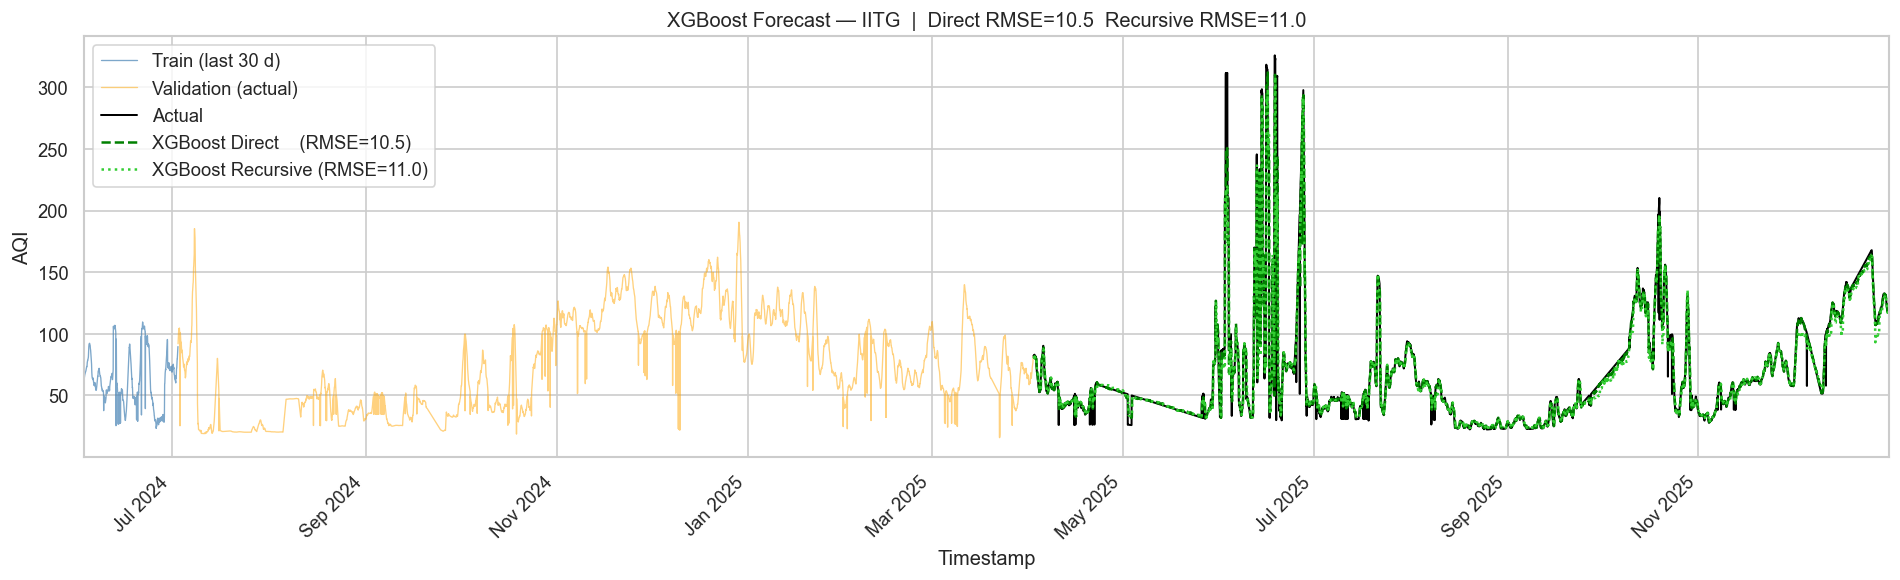

In [10]:
# ── Forecast plot ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 5))

# Last 30 days of train for context
train_tail = y_train.iloc[-30 * 24:]
ax.plot(train_tail.index, train_tail.values,
        label="Train (last 30 d)", color="steelblue", lw=0.8, alpha=0.7)

# ── ADD THIS: fill the gap with the validation period ──
ax.plot(y_val.index, y_val.values,
        color="orange", lw=0.8, alpha=0.5, label="Validation (actual)")

# Actual test values
ax.plot(y_test.index, y_test.values,
        label="Actual", color="black", lw=1.2)

# Direct forecast
ax.plot(y_test.index, pred_direct,
        label=f"XGBoost Direct    (RMSE={rmse:.1f})",
        color="green", linestyle="--", lw=1.5)

# Recursive forecast
ax.plot(y_test.index, pred_recursive,
        label=f"XGBoost Recursive (RMSE={rmse_r:.1f})",
        color="limegreen", linestyle=":", lw=1.5)

# Set x-limits to cover everything without blank stretches
ax.set_xlim(train_tail.index[0], y_test.index[-1])

ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.xticks(rotation=45, ha="right")

ax.set_xlabel("Timestamp")
ax.set_ylabel("AQI")
ax.set_title(
    f"XGBoost Forecast — {STATION_NAME}  |  "
    f"Direct RMSE={rmse:.1f}  Recursive RMSE={rmse_r:.1f}"
)
ax.legend(loc="upper left")
plt.tight_layout()
plt.savefig(f"images/{STATION_NAME}_xgb_forecast.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Feature Importance


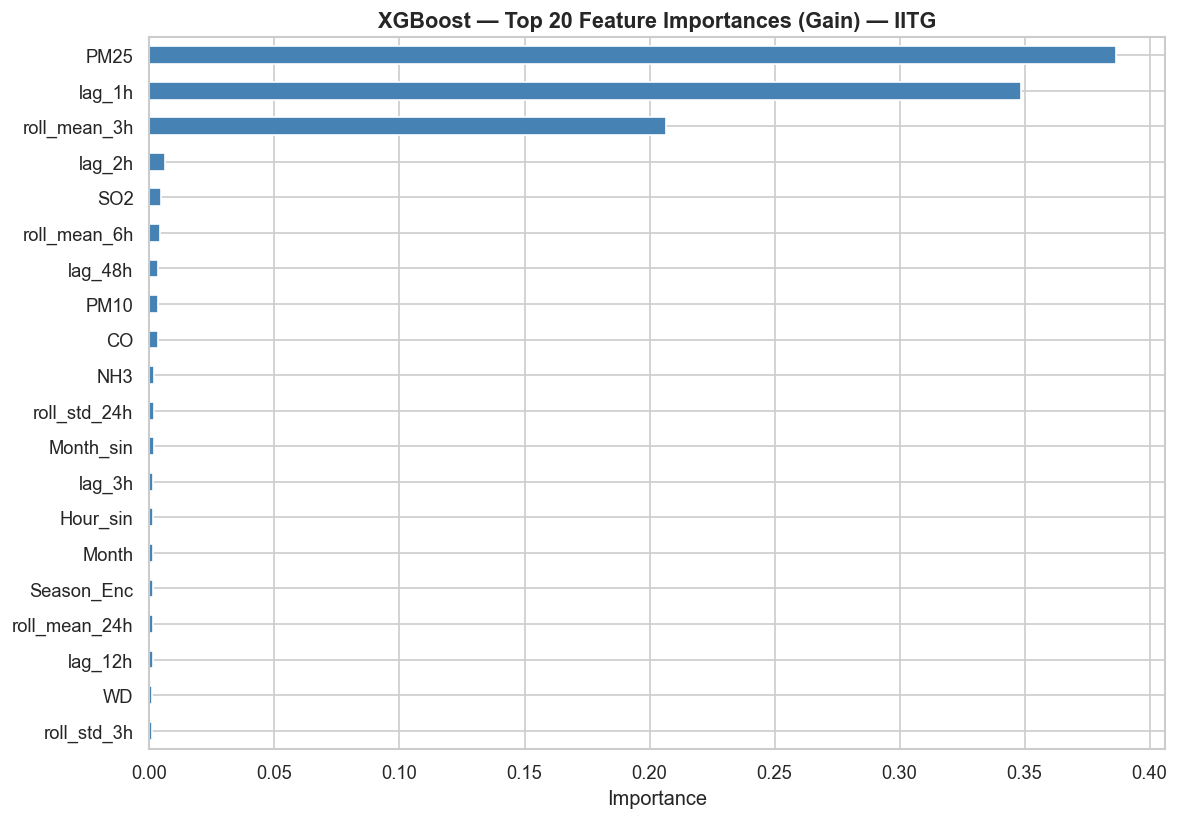

PM25            0.386690
lag_1h          0.348539
roll_mean_3h    0.206459
lag_2h          0.006298
SO2             0.004461
roll_mean_6h    0.004052
lag_48h         0.003479
PM10            0.003346
CO              0.003309
NH3             0.001961
dtype: float32


In [11]:
plt.close("all")

importance = pd.Series(
    model.feature_importances_, index=FEATURE_COLS
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
importance.head(20).plot(kind="barh", ax=ax, color="steelblue")
ax.invert_yaxis()
ax.set_title(
    f"XGBoost — Top 20 Feature Importances (Gain) — {STATION_NAME}",
    fontsize=13, fontweight="bold")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.savefig(f"images/xgboost_feature_importance_{STATION_NAME}.png", dpi=150)
plt.show()
print(importance.head(10))


## 7. Learning Curve


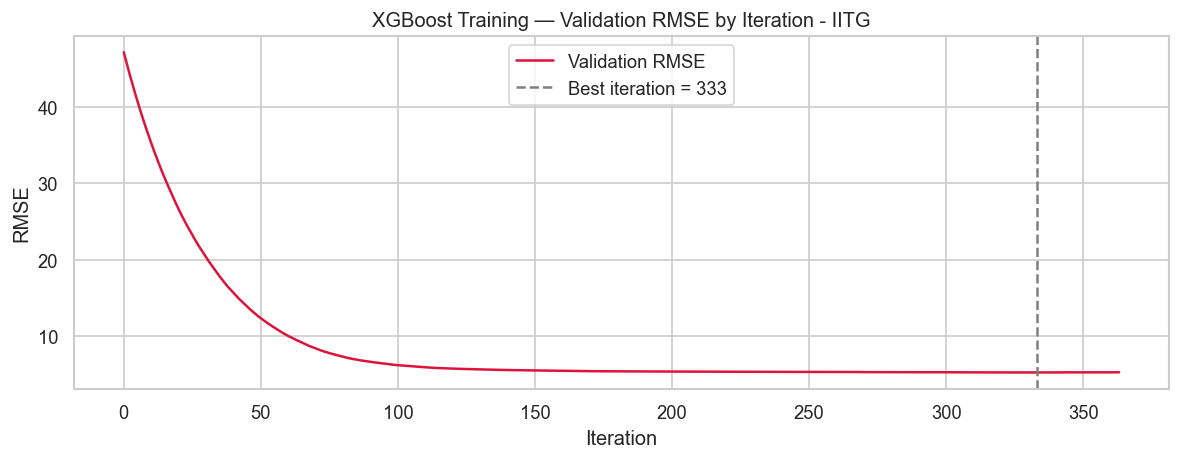

In [12]:
evals_result = model.evals_result()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(evals_result["validation_0"]["rmse"],
        label="Validation RMSE", color="crimson")
ax.axvline(model.best_iteration, linestyle="--", color="gray",
           label=f"Best iteration = {model.best_iteration}")
ax.set_title(f'XGBoost Training — Validation RMSE by Iteration — {STATION_NAME}')
ax.set_xlabel("Iteration")
ax.set_ylabel("RMSE")
ax.legend()
plt.tight_layout()
plt.savefig(f"images/xgboost_learning_curve_{STATION_NAME}.png", dpi=150)
plt.show()


## 8. Classification Metrics & Confusion Matrix

Continuous AQI predictions are mapped to discrete **Indian AQI categories**  
(Good / Satisfactory / Moderate / Poor / Very Poor / Severe)  
using the same thresholds from EDA Section 2.2.


Classification Metrics — AQI Categories (Recursive Forecast):
  Accuracy  : 0.9273
  Precision : 0.9260 (Weighted)
  Recall    : 0.9273 (Weighted)

              precision    recall  f1-score   support

        Good       0.95      0.98      0.97      3002
Satisfactory       0.91      0.93      0.92      2464
    Moderate       0.92      0.83      0.87       966
        Poor       0.62      0.61      0.61        92
   Very Poor       0.75      0.07      0.14        40

    accuracy                           0.93      6564
   macro avg       0.83      0.68      0.70      6564
weighted avg       0.93      0.93      0.92      6564



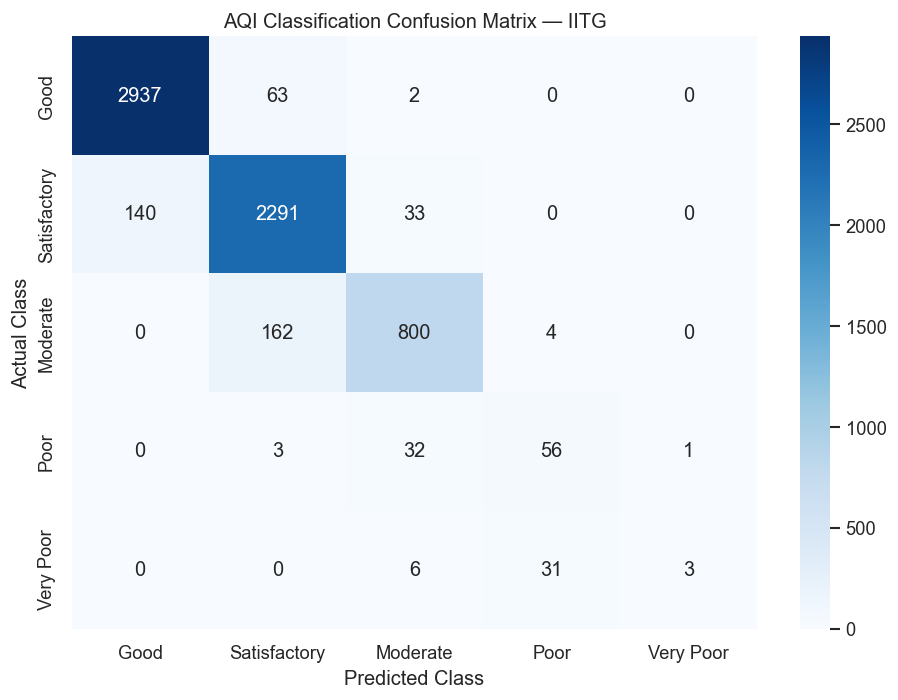

In [13]:
def categorize_aqi(aqi_values: np.ndarray) -> np.ndarray:
    """Map continuous AQI values to Indian AQI category strings."""
    cats = []
    for val in aqi_values:
        if   val <=  50: cats.append("Good")
        elif val <= 100: cats.append("Satisfactory")
        elif val <= 200: cats.append("Moderate")
        elif val <= 300: cats.append("Poor")
        elif val <= 400: cats.append("Very Poor")
        else:            cats.append("Severe")
    return np.array(cats)


y_true_cont  = y_test.values.flatten()
y_pred_cont  = pred_recursive.flatten()

y_true_class = categorize_aqi(y_true_cont)
y_pred_class = categorize_aqi(y_pred_cont)

LABELS  = ["Good", "Satisfactory", "Moderate", "Poor", "Very Poor", "Severe"]
present = [l for l in LABELS if l in y_true_class or l in y_pred_class]

acc  = accuracy_score(y_true_class, y_pred_class)
prec = precision_score(y_true_class, y_pred_class,
                       average="weighted", zero_division=0)
rec  = recall_score(y_true_class, y_pred_class,
                    average="weighted", zero_division=0)

print("Classification Metrics — AQI Categories (Recursive Forecast):")
print(f"  Accuracy  : {acc:.4f}")
print(f"  Precision : {prec:.4f} (Weighted)")
print(f"  Recall    : {rec:.4f} (Weighted)")
print()
print(classification_report(y_true_class, y_pred_class,
                            labels=present, zero_division=0))

# Confusion matrix
cm = confusion_matrix(y_true_class, y_pred_class, labels=present)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=present, yticklabels=present, ax=ax)
ax.set_title(f"AQI Classification Confusion Matrix — {STATION_NAME}")
ax.set_xlabel("Predicted Class")
ax.set_ylabel("Actual Class")
plt.tight_layout()
plt.savefig(f"images/xgboost_confusion_matrix_{STATION_NAME}.png",
            dpi=150, bbox_inches="tight")
plt.show()


## 9. AQI Category Distribution — Actual vs Predicted

Validates that the model predicts a realistic category mix.  
Compare against the full-dataset baseline in EDA Section 2.2.


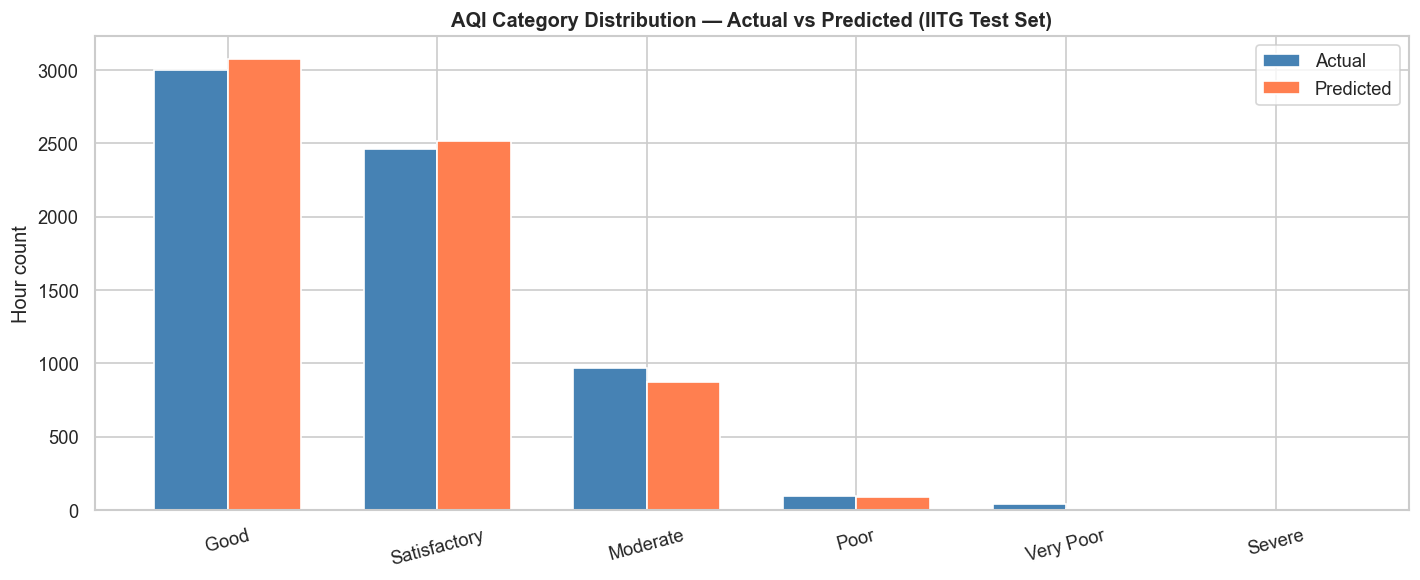

In [14]:
CAT_ORDER = ["Good", "Satisfactory", "Moderate", "Poor", "Very Poor", "Severe"]
CAT_PAL   = ["#2ecc71","#a8e063","#f1c40f","#e67e22","#e74c3c","#8e44ad"]

true_counts = pd.Series(y_true_class).value_counts().reindex(CAT_ORDER).fillna(0)
pred_counts = pd.Series(y_pred_class).value_counts().reindex(CAT_ORDER).fillna(0)

x = np.arange(len(CAT_ORDER))
w = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - w/2, true_counts.values, w, label="Actual",
       color="steelblue", edgecolor="white")
ax.bar(x + w/2, pred_counts.values, w, label="Predicted",
       color="coral", edgecolor="white")
ax.set_xticks(x)
ax.set_xticklabels(CAT_ORDER, rotation=15)
ax.set_title(
    f"AQI Category Distribution — Actual vs Predicted ({STATION_NAME} Test Set)",
    fontsize=12, fontweight="bold")
ax.set_ylabel("Hour count")
ax.legend()
plt.tight_layout()
plt.savefig(f"images/xgboost_category_distribution_{STATION_NAME}.png", dpi=150)
plt.show()


# **Residual Analyasis**

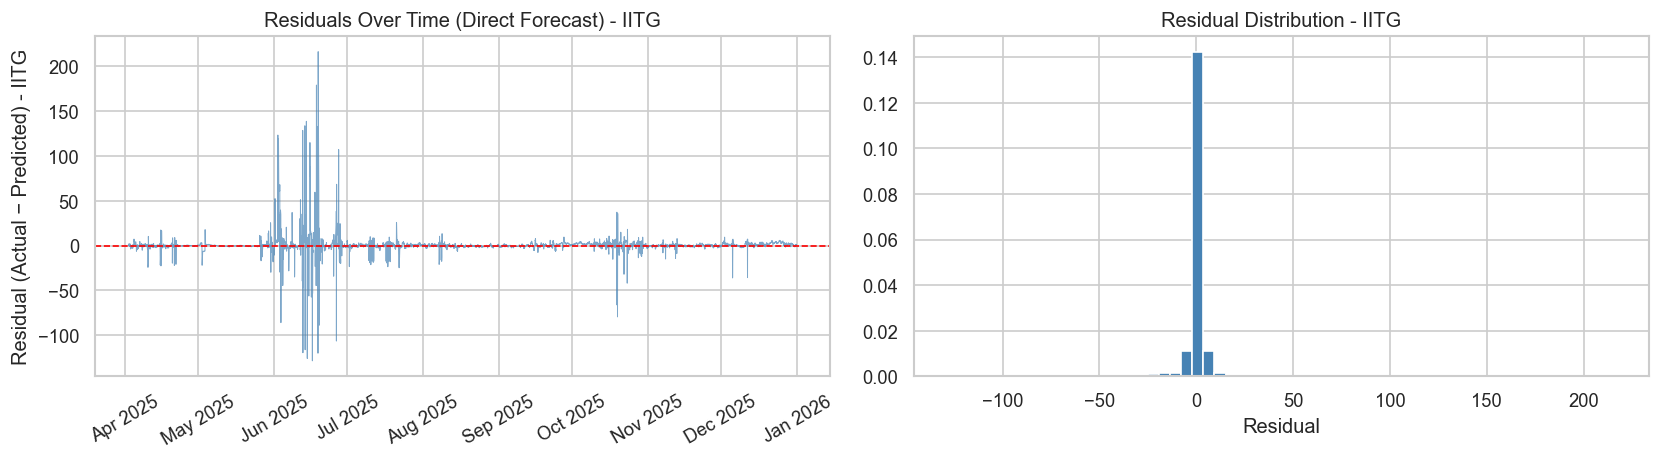

Mean residual : 0.6577
Std  residual : 10.4503


In [15]:
residuals = y_test.values - pred_direct

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(y_test.index, residuals, lw=0.6, alpha=0.7, color='steelblue')
axes[0].axhline(0, color='red', lw=1, linestyle='--')
axes[0].set_title(f'Residuals Over Time (Direct Forecast) — {STATION_NAME}')
axes[0].set_ylabel(f'Residual (Actual - Predicted) — {STATION_NAME}')
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=30)

axes[1].hist(residuals, bins=60, color='steelblue', edgecolor='white', density=True)
axes[1].set_title(f'Residual Distribution — {STATION_NAME}')
axes[1].set_xlabel('Residual')

plt.tight_layout()
plt.savefig(f'images/xgboost_residuals_{STATION_NAME.lower()}.png', dpi=150)
plt.show()

print(f'Mean residual : {residuals.mean():.4f}')
print(f'Std  residual : {residuals.std():.4f}')

## 10. Save Model


In [16]:

model_path = os.path.join('saved_models', f'{STATION_NAME.lower()}_xgboost_aqi.pkl')
joblib.dump(model, model_path)

# Save feature list for reproducibility
import json
os.makedirs('outputs', exist_ok=True)
feat_path = os.path.join('outputs', f'{STATION_NAME}_xgboost_features.json')
with open(feat_path, 'w') as fp:
    json.dump(FEATURE_COLS, fp, indent=2)
print(f"✅ Model saved : {model_path}")


✅ Model saved : saved_models\iitg_xgboost_aqi.pkl
